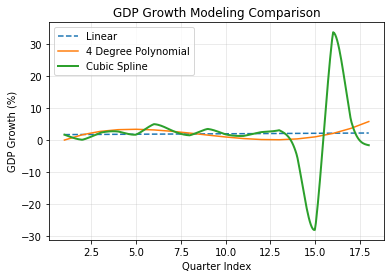

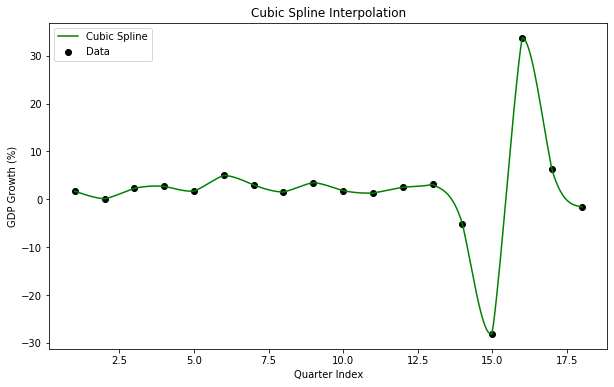

RMSE Linear: 10.587054083951248
RMSE Polynomial: 10.47860720346316


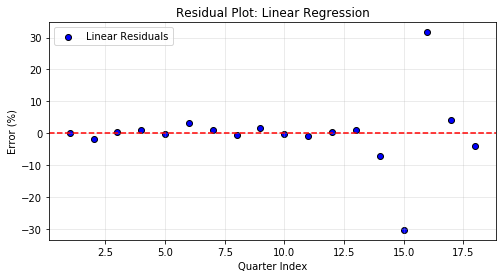

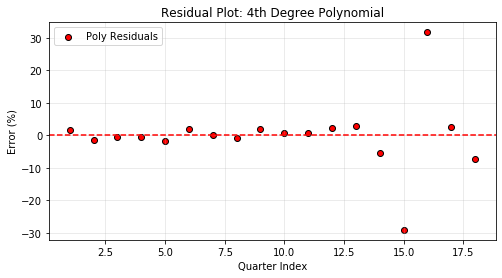

In [22]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1,19)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 
    1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6
])

## LEAST SQUARES SUPER MANUAL

n = len(x)

sumx = np.sum(x)
sumy = np.sum(y)
sumx2 = np.sum(x**2)
sumxy = np.sum(x*y)

m = (n*sumxy - sumx*sumy) / (n*sumx2 - sumx**2)
b = (sumy - m*sumx) / n

##predict
ylin = m*x + b

##POLYNOMIAL
degree = 4
maxpow = 2 * degree
S = []
for k in range(maxpow + 1):
    S.append(np.sum(x**k))
    
T = []
for k in range(degree + 1):
    T.append(np.sum((x**k) * y))

A = np.zeros((degree+1, degree+1))
bvec = np.zeros(degree+1)

for i in range(degree+1):
    for j in range(degree+1):
        A[i, j] = S[i+j]
    bvec[i] = T[i]

coeffs = np.linalg.solve(A , bvec)

def polyeval(xvals, coeffs):
    yout = np.zeros_like(xvals, dtype=float)
    for i in range(len(coeffs)):
        yout += coeffs[i] * (xvals**i)
    return yout

ypoly = polyeval(x, coeffs)




##CUBIC SPLINE TIME
n = len(x)
h = np.diff(x)

A = np.zeros((n-2, n-2))
rhs = np.zeros(n-2)

for i in range(1, n-1):
    if i-2 >= 0:
        A[i-1, i-2] = h[i-1]
        
    A[i-1, i-1] = 2*(h[i-1] + h[i])
    
    if i < n-2:
        A[i-1, i] = h[i]
        
    rhs[i-1] = 3*((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1])/h[i-1])
    
M = np.zeros(n)
M[1:-1] = np.linalg.solve(A, rhs)

def evalspline(xq, x, y, M):
    for i in range(len(x)-1):
        if x[i] <= xq <= x[i+1]:
            h = x[i+1] - x[i]
            a = (x[i+1] - xq)/h
            b = (xq - x[i])/h
            
            return (a*y[i] + b*y[i+1] + ((a**3 - a)*M[i] + (b**3 - b)*M[i+1]) * h**2 / 6)
    
    return None

##applying it all

xdense = np.linspace(min(x), max(x), 300)
yspline = np.array([evalspline(xi, x, y, M) for xi in xdense])

##PLOT ALL TOGETHER
plt.plot(x, ylin, label="Linear", linestyle='--')
plt.plot(x, ypoly, label="4 Degree Polynomial")
plt.plot(xdense, yspline, label="Cubic Spline", linewidth=2)

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("GDP Growth Modeling Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Full disclosure, Gemini has helped me debug a majority of this code since the tridiagonal matrix. 

reslinear = y - ylin
respoly = y - ypoly


plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label="Data")
plt.plot(xdense, yspline, color='green', label="Cubic Spline")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.show()

rmselinear = np.sqrt(np.mean(reslinear**2))
rmsepoly = np.sqrt(np.mean(respoly**2))

print("RMSE Linear:", rmselinear)
print("RMSE Polynomial:", rmsepoly)
## Linear Residuals
plt.figure(figsize=(8, 4))
plt.scatter(x, reslinear, color='blue', edgecolor='black', label="Linear Residuals")
plt.axhline(0, color='red', linestyle='--') # Zero-error line
plt.xlabel("Quarter Index")
plt.ylabel("Error (%)")
plt.title("Residual Plot: Linear Regression")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Polynomial Residuals
plt.figure(figsize=(8, 4))
plt.scatter(x, respoly, color='red', edgecolor='black', label="Poly Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Quarter Index")
plt.ylabel("Error (%)")
plt.title("Residual Plot: 4th Degree Polynomial")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



In [ ]:
##Questions
## Cubic Spline
    ## 1) We set the boundary M1 = M18 = 0 for natural spline
    ## The unkowns are the second derivatices at each interior point
    ## 2) The spline exhibits rapid oscillations to hit the pandemic outliers
    ## Which does not reflect typical GDP behaviour outside of COVID
    ## Other than this the interpolant is pretty smooth
    ## 3) The -28.1% value creates Runges phenomenon, since forced interpolation of the data point causes instability in 
    ## other intervals
    ## Weighted least squares could handle the data point better it prioritizes a stable trend rather than each point
## Polynomial and Least Squares Comparison
    ## 1) The spline does a great job of reproducing every point but doesn't predict very well
    ## However the 4th degree polynomial captures the broader shape
    ## Ultimately there is a trade off between approximation and interpolation
    ## 2) A linear trend does not really make sense for this data as it assumes constant growth
    ## Economics mostly works in cycles which cannot be accurately depicted by a linear growth rate
## Method Justification
    ## 1) For a policymaker, I would recommend the Cubic Spline. It creates smoothness and more plausible transitions between quarters.
    ## But for forecasting purposes, least-Squares is more reliable because it is more resistent to outliers.

Technical Report

     This report analyzes the United States' quarterly GDP growth from 2010 to 2023 using
Least Squares Linear Regression, Polynomial Fitting, and Cubic Spline Interpolation.
The objective of this report is to evaluate how these methods handle the high volatility and outliers,
especially the results from the pandemic.


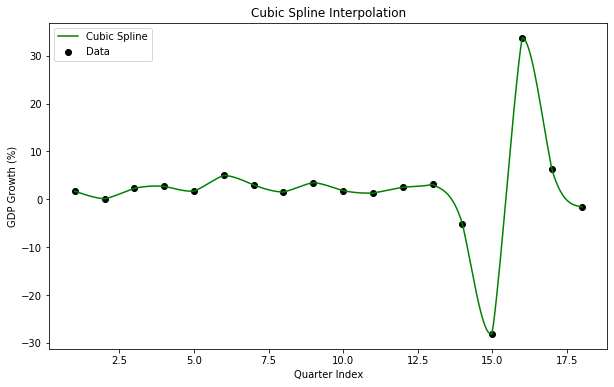


     The spline was constructed by manually setting up a tridiagonal matrix for the curvature at each point.
I learned this method from UT Austin CS major Cheza Taylor, who coached me through the for loops and arrays.
The spline plot hits every point precisely, but the boundary conditions and continuity requirements cause
an overshoot during the pandemic.
     Because it is an interpolant, the spline cannot tell between a long term trend and a temporary shock.
This leads to a sensetivity to outliers which limits the graphs economic modeling ability.


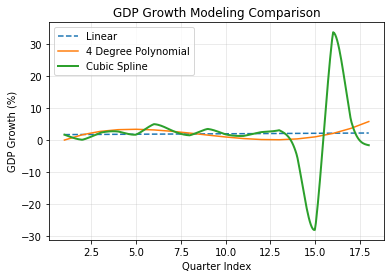

     Normal Equations were implemented from scratch to fit a linear trend as well as a 4th degree polynomial. The
polynomial fit resulted in a lower RMSE compared to the linear model, as the extra degrees of freedom allowed
it to curve toward the outliers.The straight line of the residual graph is an underfit and shows a non random pattern.

RMSE Linear: 10.587054083951248
RMSE Polynomial: 10.47860720346316


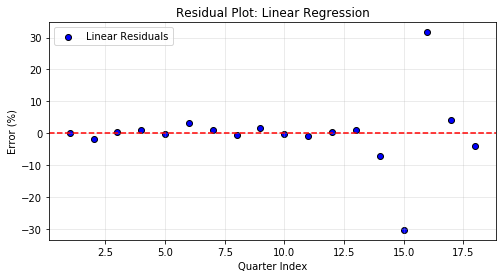

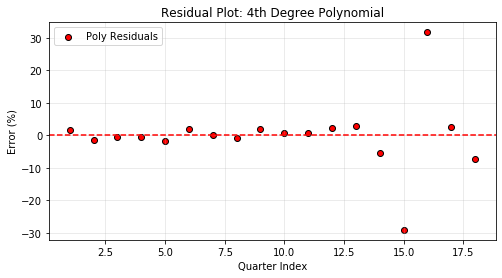

     The best model for policymakers will be the most efficient and stable. Using the Big O, we determine that Linear
Least Squares is the most efficient but least flexible option. Polynomial Fitting works well the lower the degree,
but the increasing condition of the Vandermonde matrix limits this. Cubic Spline offers great efficiency as well
as local smoothness unlike the polynomials.

Overall, due to its O(n) efficiency and smoothness, the Cubic Spline is the best method for interpolation. However,
Polynomial fit is recommended in cases of trend analysis as it works together both accuracy and stability. 

Linear regression identifies base growth, polynomial fitting captures the whole curve, and Cubic Splines provide
precise interpolation. While the Spline is superior in its complexity, it is weakened by the outliers of 2020.


In [29]:
print("Technical Report") 
print()
print("     This report analyzes the United States' quarterly GDP growth from 2010 to 2023 using")
print("Least Squares Linear Regression, Polynomial Fitting, and Cubic Spline Interpolation.")
print("The objective of this report is to evaluate how these methods handle the high volatility and outliers,")
print("especially the results from the pandemic.")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label="Data")
plt.plot(xdense, yspline, color='green', label="Cubic Spline")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.show()
print()
print("     The spline was constructed by manually setting up a tridiagonal matrix for the curvature at each point.")
print("I learned this method from UT Austin CS major Cheza Taylor, who coached me through the for loops and arrays.")
print("The spline plot hits every point precisely, but the boundary conditions and continuity requirements cause")
print("an overshoot during the pandemic.")
print("     Because it is an interpolant, the spline cannot tell between a long term trend and a temporary shock.")
print("This leads to a sensetivity to outliers which limits the graphs economic modeling ability.")

plt.plot(x, ylin, label="Linear", linestyle='--')
plt.plot(x, ypoly, label="4 Degree Polynomial")
plt.plot(xdense, yspline, label="Cubic Spline", linewidth=2)

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("GDP Growth Modeling Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("     Normal Equations were implemented from scratch to fit a linear trend as well as a 4th degree polynomial. The") 
print("polynomial fit resulted in a lower RMSE compared to the linear model, as the extra degrees of freedom allowed")
print("it to curve toward the outliers.The straight line of the residual graph is an underfit and shows a non random pattern.")
print()
print("RMSE Linear:", rmselinear)
print("RMSE Polynomial:", rmsepoly)
## Linear Residuals
plt.figure(figsize=(8, 4))
plt.scatter(x, reslinear, color='blue', edgecolor='black', label="Linear Residuals")
plt.axhline(0, color='red', linestyle='--') # Zero-error line
plt.xlabel("Quarter Index")
plt.ylabel("Error (%)")
plt.title("Residual Plot: Linear Regression")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Polynomial Residuals
plt.figure(figsize=(8, 4))
plt.scatter(x, respoly, color='red', edgecolor='black', label="Poly Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Quarter Index")
plt.ylabel("Error (%)")
plt.title("Residual Plot: 4th Degree Polynomial")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print("     The best model for policymakers will be the most efficient and stable. Using the Big O, we determine that Linear") 
print("Least Squares is the most efficient but least flexible option. Polynomial Fitting works well the lower the degree,")
print("but the increasing condition of the Vandermonde matrix limits this. Cubic Spline offers great efficiency as well")
print("as local smoothness unlike the polynomials.")
print()
print("Overall, due to its O(n) efficiency and smoothness, the Cubic Spline is the best method for interpolation. However,")
print("Polynomial fit is recommended in cases of trend analysis as it works together both accuracy and stability. ")
print()
print("Linear regression identifies base growth, polynomial fitting captures the whole curve, and Cubic Splines provide")
print("precise interpolation. While the Spline is superior in its complexity, it is weakened by the outliers of 2020.")